In [3]:
import pandas as pd

df = pd.read_csv("../data/diabetesdata.csv")

print(df.head())
print(df.shape)
print(df.columns)
print(df.info())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
(768, 9)
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Cou

In [4]:
print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nZero values:")
print((df == 0).sum())

print("\nOutcome distribution:")
print(df["Outcome"].value_counts())

Dataset shape: (768, 9)

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Zero values:
Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

Outcome distribution:
Outcome
0    500
1    268
Name: count, dtype: int64


In [6]:
import numpy as np

In [7]:
columns_with_zero = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

df[columns_with_zero] = df[columns_with_zero].replace(0, np.nan)

In [8]:
for column in columns_with_zero:
    df[column] = df[column].fillna(df[column].median())

In [9]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [10]:
print(df["Outcome"].value_counts())

Outcome
0    500
1    268
Name: count, dtype: int64


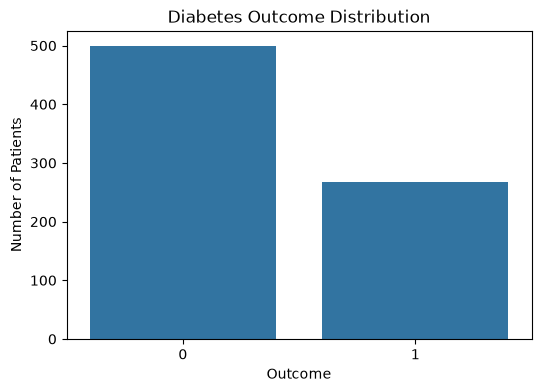

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(x="Outcome", data=df)

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")

plt.show()

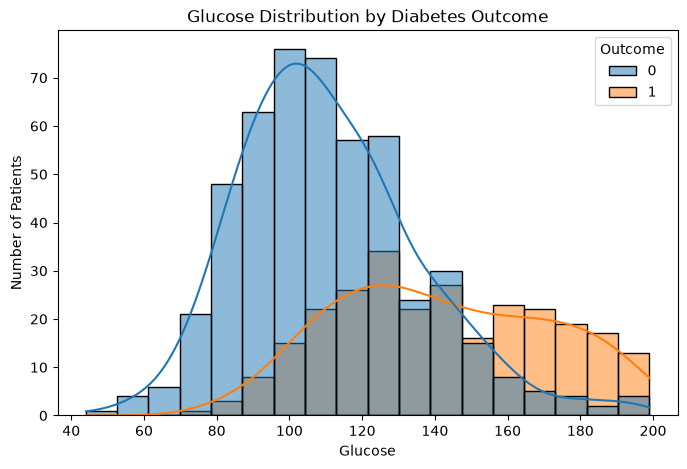

In [13]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Glucose", hue="Outcome", kde=True)

plt.title("Glucose Distribution by Diabetes Outcome")
plt.xlabel("Glucose")
plt.ylabel("Number of Patients")

plt.show()

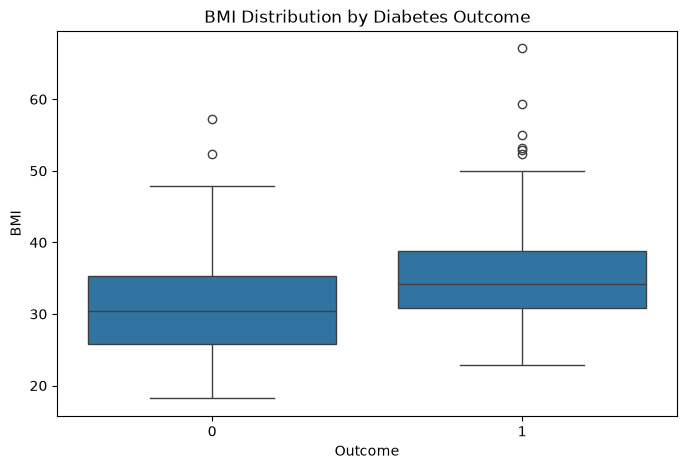

In [14]:
plt.figure(figsize=(8, 5))

sns.boxplot(x="Outcome", y="BMI", data=df)

plt.title("BMI Distribution by Diabetes Outcome")
plt.xlabel("Outcome")
plt.ylabel("BMI")

plt.show()

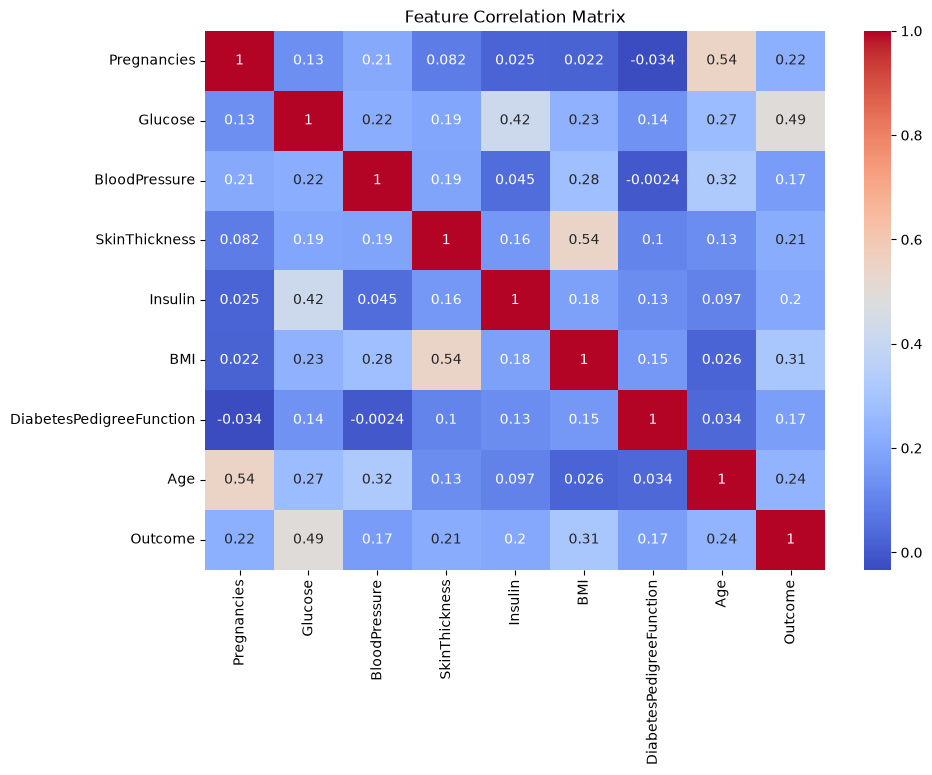

In [15]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Matrix")

plt.show()

In [16]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (768, 8)
y shape: (768,)


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (614, 8)
Testing data: (154, 8)


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Before scaling:")
print(X_train.head())

print("\nAfter scaling:")
print(X_train_scaled[:5])

Before scaling:
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
353            1     90.0           62.0           12.0     43.0  27.2   
711            5    126.0           78.0           27.0     22.0  29.6   
373            2    105.0           58.0           40.0     94.0  34.9   
46             1    146.0           56.0           29.0    125.0  29.7   
682            0     95.0           64.0           39.0    105.0  44.6   

     DiabetesPedigreeFunction  Age  
353                     0.580   24  
711                     0.439   40  
373                     0.225   25  
46                      0.564   29  
682                     0.366   22  

After scaling:
[[-0.85135507 -1.05642747 -0.82674004 -1.91818693 -1.20336073 -0.76947697
   0.31079384 -0.79216928]
 [ 0.35657564  0.14439907  0.47777235 -0.22987447 -1.47019479 -0.41749769
  -0.11643851  0.56103382]
 [-0.5493724  -0.55608308 -1.15286813  1.23332967 -0.55533518  0.3597899
  -0.76486207 -0.70759409]

In [ ]:
# Train the SVM model

In [ ]:
from sklearn.svm import SVC

model = SVC(kernel="linear")

model.fit(X_train_scaled, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [20]:
y_pred = model.predict(X_test_scaled)

print("Predicted:", y_pred[:20])
print("Actual:   ", y_test.values[:20])

Predicted: [1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 1 0]
Actual:    [0 0 0 1 0 0 1 1 0 0 0 1 0 0 1 1 0 0 0 0]


In [24]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7012987012987013

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.59      0.48      0.53        54

    accuracy                           0.70       154
   macro avg       0.67      0.65      0.66       154
weighted avg       0.69      0.70      0.69       154


Confusion Matrix:
[[82 18]
 [28 26]]


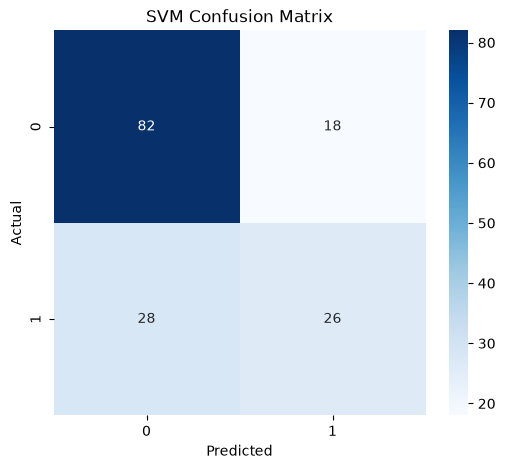

In [25]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

<!-- Train the Logistic Regression Model -->

In [26]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train_scaled, y_train)
logistic_pred = logistic_model.predict(X_test_scaled)
logistic_accuracy = accuracy_score(y_test, logistic_pred)

print("Logistic Regression Accuracy:", logistic_accuracy)
print("Percentage:", logistic_accuracy * 100)
print(classification_report(y_test, logistic_pred))
print(confusion_matrix(y_test, logistic_pred))

Logistic Regression Accuracy: 0.7077922077922078
Percentage: 70.77922077922078
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154

[[82 18]
 [27 27]]


In [27]:
results = pd.DataFrame({
    "Model": ["SVM", "Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, logistic_pred)
    ]
})

results

,Model,Accuracy
0,SVM,0.701299
1,Logistic Regression,0.707792


<!-- Train the SVC (rbf) Model -->

In [28]:
from sklearn.svm import SVC

rbf_model = SVC(kernel="rbf")

rbf_model.fit(X_train_scaled, y_train)

rbf_pred = rbf_model.predict(X_test_scaled)

print("RBF SVM Accuracy:", accuracy_score(y_test, rbf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rbf_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rbf_pred))

RBF SVM Accuracy: 0.7402597402597403

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.84      0.81       100
           1       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154


Confusion Matrix:
[[84 16]
 [24 30]]


In [ ]:
# Hyperparameter tuning

In [29]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.01, 0.1, 1]
}

grid = GridSearchCV(
    SVC(kernel="rbf"),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("Best CV Accuracy:")
print(grid.best_score_)

Best Parameters:
{'C': 10, 'gamma': 0.01}
Best CV Accuracy:
0.7736372117819539


In [31]:
best_model = grid.best_estimator_

tuned_pred = best_model.predict(X_test_scaled)

print("Test Accuracy:")
print(accuracy_score(y_test, tuned_pred))

print("\nClassification Report:")
print(classification_report(y_test, tuned_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, tuned_pred))

Test Accuracy:
0.6948051948051948

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.82      0.78       100
           1       0.58      0.46      0.52        54

    accuracy                           0.69       154
   macro avg       0.66      0.64      0.65       154
weighted avg       0.68      0.69      0.69       154


Confusion Matrix:
[[82 18]
 [29 25]]


In [32]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

# Prepare original features
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Create ML pipeline
svm_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf"))
])

# Train
svm_pipeline.fit(X_train, y_train)

# Predict
pipeline_pred = svm_pipeline.predict(X_test)

print("Test Accuracy:")
print(accuracy_score(y_test, pipeline_pred))

print("\nClassification Report:")
print(classification_report(y_test, pipeline_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, pipeline_pred))

Test Accuracy:
0.7402597402597403

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.84      0.81       100
           1       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154


Confusion Matrix:
[[84 16]
 [24 30]]


In [33]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__C": [0.1, 1, 10, 100],
    "model__gamma": ["scale", 0.01, 0.1, 1]
}

grid_pipeline = GridSearchCV(
    svm_pipeline,
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid_pipeline.fit(X_train, y_train)

print("Best Parameters:")
print(grid_pipeline.best_params_)

print("\nBest CV Accuracy:")
print(grid_pipeline.best_score_)

Best Parameters:
{'model__C': 10, 'model__gamma': 0.01}

Best CV Accuracy:
0.7752765560442489


In [34]:
best_pipeline = grid_pipeline.best_estimator_

tuned_pipeline_pred = best_pipeline.predict(X_test)

print("Test Accuracy:")
print(accuracy_score(y_test, tuned_pipeline_pred))

print("\nClassification Report:")
print(classification_report(y_test, tuned_pipeline_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, tuned_pipeline_pred))

Test Accuracy:
0.6948051948051948

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.82      0.78       100
           1       0.58      0.46      0.52        54

    accuracy                           0.69       154
   macro avg       0.66      0.64      0.65       154
weighted avg       0.68      0.69      0.69       154


Confusion Matrix:
[[82 18]
 [29 25]]


<!-- Final Model (RBF SVM) -->

In [35]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

final_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf"))
])

final_model.fit(X_train, y_train)

print("Final model trained successfully!")

Final model trained successfully!


In [37]:
import joblib

joblib.dump(final_model, "../models/diabetes_model.pkl")

print("Model saved successfully!")

Model saved successfully!


<!-- Testing the Final Model -->

In [38]:
import joblib

# Load saved model
loaded_model = joblib.load("../models/diabetes_model.pkl")

print("Saved model loaded successfully!")

Saved model loaded successfully!


In [39]:
# Take one sample from the test dataset
sample = X_test.iloc[[0]]

# Actual outcome
actual = y_test.iloc[0]

# Prediction
prediction = loaded_model.predict(sample)[0]

print("Actual Outcome:", actual)
print("Predicted Outcome:", prediction)

Actual Outcome: 0
Predicted Outcome: 1


<!-- Rebuilding New Model -->

In [1]:
import pandas as pd
import numpy as np

# Reload the original CSV
original_df = pd.read_csv("../data/diabetesdata.csv")

print(original_df.head())
print(original_df.shape)

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
(768, 9)


In [2]:
X = original_df.drop("Outcome", axis=1)
y = original_df["Outcome"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (768, 8)
y shape: (768,)


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (614, 8)
Testing data: (154, 8)


In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Columns where 0 represents a missing/invalid medical measurement
zero_invalid_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

# Columns where 0 is a valid value
normal_columns = [
    "Pregnancies",
    "DiabetesPedigreeFunction",
    "Age"
]

preprocessor = ColumnTransformer([
    (
        "medical_imputer",
        SimpleImputer(
            missing_values=0,
            strategy="median"
        ),
        zero_invalid_columns
    ),
    (
        "normal_imputer",
        SimpleImputer(strategy="median"),
        normal_columns
    )
])

final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf"))
])

print("Pipeline created successfully!")

Pipeline created successfully!


In [5]:
final_model.fit(X_train, y_train)

print("Final model trained successfully!")

Final model trained successfully!


In [6]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

final_pred = final_model.predict(X_test)

print("Test Accuracy:")
print(accuracy_score(y_test, final_pred))

print("\nClassification Report:")
print(classification_report(y_test, final_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_pred))

Test Accuracy:
0.7402597402597403

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.84      0.81       100
           1       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154


Confusion Matrix:
[[84 16]
 [24 30]]


In [7]:
import joblib

joblib.dump(final_model, "../models/diabetes_model.pkl")

print("Corrected model saved successfully!")

Corrected model saved successfully!


In [8]:
loaded_model = joblib.load("../models/diabetes_model.pkl")

print("Corrected saved model loaded successfully!")

Corrected saved model loaded successfully!


In [9]:
# Same sample we tested through the website
sample_data = pd.DataFrame([{
    "Pregnancies": 6,
    "Glucose": 148,
    "BloodPressure": 72,
    "SkinThickness": 35,
    "Insulin": 0,
    "BMI": 33.6,
    "DiabetesPedigreeFunction": 0.627,
    "Age": 50
}])

prediction = loaded_model.predict(sample_data)[0]

print("Predicted Outcome:", prediction)

Predicted Outcome: 1
